<a href="https://colab.research.google.com/github/hassan1662n/Deep-learning-projects/blob/main/pizza_steak_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile

!wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

# unzip
zip_ref = zipfile.ZipFile('pizza_steak.zip')
zip_ref.extractall()
zip_ref.close()


--2026-09-09 13:49:28--  https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 34.3.0.27, 34.144.170.27, 104.154.125.27, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|34.3.0.27|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109540975 (104M) [application/zip]
Saving to: ‘pizza_steak.zip’

pizza_steak.zip     100%[===================>] 104.47M  21.5MB/s    in 6.3s    

2026-09-09 13:49:35 (16.7 MB/s) - ‘pizza_steak.zip’ saved [109540975/109540975]



# inspect the data

In [2]:
!ls pizza_steak

test  train


In [3]:
!ls pizza_steak/train

pizza  steak


In [4]:
import os

for dirpath, dirnames, filenames in os.walk('pizza_steak'):
  print(f"there are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")


there are 2 directories and 0 images in 'pizza_steak'.
there are 2 directories and 0 images in 'pizza_steak/test'.
there are 0 directories and 250 images in 'pizza_steak/test/steak'.
there are 0 directories and 250 images in 'pizza_steak/test/pizza'.
there are 2 directories and 0 images in 'pizza_steak/train'.
there are 0 directories and 750 images in 'pizza_steak/train/steak'.
there are 0 directories and 750 images in 'pizza_steak/train/pizza'.


In [5]:
import pathlib
import numpy as np

data_dir = pathlib.Path("pizza_steak/train")
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(class_names)

['pizza' 'steak']


In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def view_random_image(target_dir, target_class):
  target_folder = target_dir + target_class
  random_image = random.sample(os.listdir(target_folder), 1)
  print(random_image)

  img = mpimg.imread(target_folder + "/" + random_image[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off")
  print(f"image shape: {img.shape}")

  return img

['3393547.jpg']
image shape: (384, 512, 3)


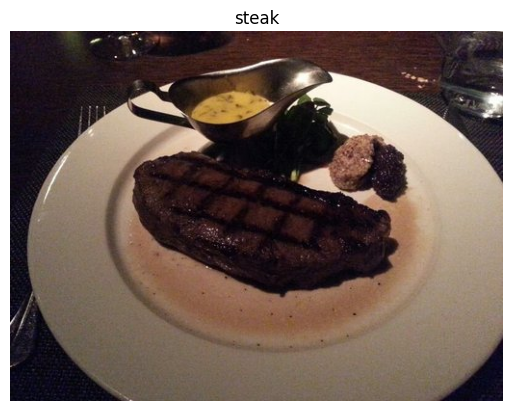

In [11]:
img = view_random_image(target_dir="pizza_steak/train/", target_class="steak")

# now convert image into tensors and then do normalization(into 0 and 1)

In [12]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tf.random.set_seed(42)

# preprocess
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

train_dir = "pizza_steak/train/"
test_dir = "pizza_steak/test/"

train_data = train_datagen.flow_from_directory(train_dir,
                                               batch_size=32,
                                               target_size=(224, 224),
                                               class_mode="binary",
                                               seed=42)

valid_data = valid_datagen.flow_from_directory(test_dir,
                                               batch_size=32,
                                               target_size=(224, 224),
                                               class_mode="binary",
                                               seed=42)

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [13]:
model_1 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=10,
                         kernel_size=3,
                         activation="relu",
                         input_shape=(224, 224, 3)),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2,
                             padding="valid"),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model_1.compile(loss="binary_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

In [15]:
history_1 = model_1.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 17s 247ms/step - accuracy: 0.6767 - loss: 0.6191 - val_accuracy: 0.8180 - val_loss: 0.4520
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 187ms/step - accuracy: 0.7967 - loss: 0.4646 - val_accuracy: 0.8260 - val_loss: 0.4166
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.8133 - loss: 0.4337 - val_accuracy: 0.8580 - val_loss: 0.3730
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 138ms/step - accuracy: 0.8233 - loss: 0.4054 - val_accuracy: 0.8160 - val_loss: 0.3872
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - accuracy: 0.8333 - loss: 0.3963 - val_accuracy: 0.8500 - val_loss: 0.3591


In [16]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

Text(0.5, 0, 'epoch')

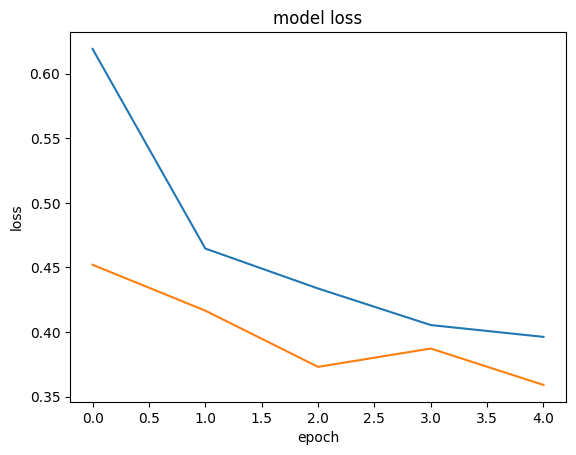

In [17]:
plt.plot(history_1.history['loss'])
plt.plot(history_1.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')

Text(0.5, 0, 'epoch')

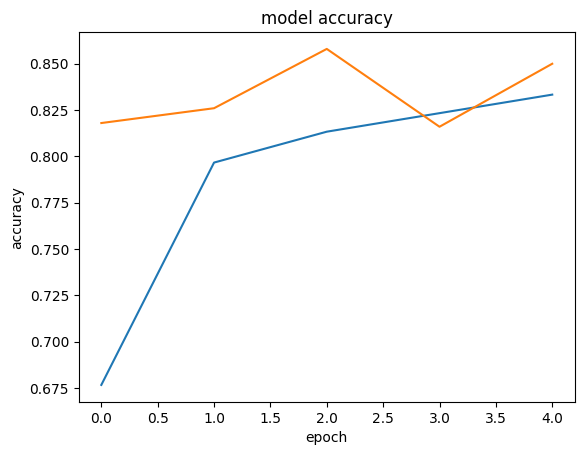

In [19]:
plt.plot(history_1.history['accuracy'])
plt.plot(history_1.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')

In [18]:
model_1.evaluate(valid_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.8500 - loss: 0.3591


[0.35906967520713806, 0.8500000238418579]

Here are some strategies to improve the accuracy of a CNN model:


---


**Adjust model architecture:**

Increase the depth or width of the network by adding more convolutional layers or filters to capture more complex features.
Consider using different types of layers such as residual connections or batch normalization to enhance the learning process.
Experiment with different network architectures or pre-trained models to leverage their learned features.


---


**Data augmentation:**

Increase the size of your training dataset by applying various data augmentation techniques such as random rotations, translations, flips, zooms, or brightness adjustments.
Augmenting the data helps the model generalize better and learn more robust features.


---


**Regularization techniques:**

Apply regularization techniques to prevent overfitting, such as L1 or L2 regularization, dropout, or early stopping.
Regularization helps in reducing the model's reliance on specific features and encourages it to learn more generalizable representations.


---


**Hyperparameter tuning:**

Experiment with different learning rates, batch sizes, optimizer algorithms (e.g., Adam, RMSprop, SGD), and activation functions to find the optimal combination.
Use techniques like grid search or random search to systematically explore the hyperparameter space.


---


**Increase the training data:**

Collect more data for training, if possible. Having a larger and diverse dataset can help the model generalize better and improve accuracy.
Alternatively, consider using techniques like data synthesis or transfer learning to leverage pre-existing datasets.


---


**Handle class imbalance:**

If your dataset has class imbalance, where some classes have significantly fewer samples, apply techniques like oversampling, undersampling, or class weighting to balance the data distribution.


---


**Optimize model convergence:**

Experiment with different optimization techniques like learning rate scheduling or adaptive learning rate algorithms to ensure smoother convergence during training.


---


**Analyze and debug:**

Analyze misclassified samples to understand patterns or trends that the model might struggle with.

Use techniques like confusion matrices or precision-recall curves to identify specific areas of improvement.

Remember, improving model accuracy is an iterative process. It often requires experimentation, careful analysis, and a deep understanding of the problem domain. Additionally, consider the limitations of the dataset and the complexity of the task at hand when setting expectations for accuracy improvement

